# Final_02_post.ipynb 步驟目錄
---
| Step | 內容 | 使用資料 | 輸出檔案 |
|---:|---|---|---|
| 1 | 讀取第一階段輸出資料 | `Taipei_grid_full_risk.geojson`, `taipei_road_grid_segments.geojson`, `taipei_shelters_join_500m.geojson`, `taipei_drive.graphml`, `TOWN_MOI_1140318.shp` | - |
| 2 | 讀取並篩選臺北市雨量資料 | `data/rain_20240418.csv` | - |
| 3 | 擷取指定時間雨量 | `rain_tp` | - |
| 4 | Kriging 雨量內插至 grid | `rain_past3hr_station`, `rain_past6hr_station`, `rain_past24hr_station`, `Taipei_grid_full_risk.geojson` | - |
| 5 | 視覺化雨量與不確定度 | `g_rain` | - |
| 6 | 輸出含雨量資訊的 grid | `g_rain`, `Taipei_grid_full_risk.geojson` | `output/Taipei_grid_with_rain_post.geojson`, `output/Taipei_grid_with_rain_post.csv` |
| 7 | 建立 post map | `grid_rain`, `edges_gdf`, `shelters`, `taipei_boundary` | `output/Taipei_post_map.html` |
| 8 | 定義道路車速與災害影響函式 | 道路類型、雨量、風險規則 | - |
| 9 | 計算 road-grid 災後通行時間 | `road_grid_segments`, `grid_rain` | `output/road_grid_traveling.csv` |

## Input Data Loading
---

This step loads the output files generated from the pre-processing stage and prepares them for post-disaster analysis. All spatial data are projected to `EPSG:3826`, which is suitable for distance and area calculation in Taiwan.

The following files are loaded:

| Variable name | File path | Description |
|---|---|---|
| g | `output/Taipei_grid_full_risk.geojson` | Taipei grid dataset with terrain, river, historical flooding, slope, and total flood risk attributes |
| road_grid_segments | `output/taipei_road_grid_segments.geojson` | Road segments clipped by grid cells; each record represents a road segment inside one grid |
| shelters | `output/taipei_shelters_join_500m.geojson` | Taipei shelters matched with nearby road segments within 500 meters |
| G | `output/taipei_drive.graphml` | Taipei road network graph |
| nodes_gdf | derived from G | Road network nodes converted from the graph |
| edges_gdf | derived from G | Road network edges converted from the graph |
| taipei_boundary | `data/TOWN_MOI_1140318/TOWN_MOI_1140318.shp` | Taipei City administrative district boundaries |
| boundary | derived from `taipei_boundary` | Dissolved Taipei City boundary used as the study area boundary |

The script first checks whether all required files exist. If any required file is missing, an error is raised to prevent the following analysis from running with incomplete data.

After loading, the script prints the number of records and CRS of each dataset to confirm that the data were read correctly.

In [1]:
# Cell 1: 讀取第一階段輸出資料

from pathlib import Path

import geopandas as gpd
import osmnx as ox

TARGET_CRS = "EPSG:3826"

# ===== 路徑設定 =====
grid_path = Path("output/Taipei_grid_full_risk.geojson")
road_grid_path = Path("output/taipei_road_grid_segments.geojson")
shelter_path = Path("output/taipei_shelters_join_500m.geojson")
town_path = Path("data/TOWN_MOI_1140318/TOWN_MOI_1140318.shp")
graph_path = Path("output/taipei_drive.graphml")

# ===== 檢查檔案是否存在 =====
required_paths = {
    "grid": grid_path,
    "road_grid_segments": road_grid_path,
    "shelters": shelter_path,
    "town": town_path,
    "road_graph": graph_path,
}

missing_paths = {
    name: path
    for name, path in required_paths.items()
    if not path.exists()
}

if missing_paths:
    raise FileNotFoundError(f"找不到檔案: {missing_paths}")

# ===== 1) 讀取風險 grid =====
g = gpd.read_file(grid_path).to_crs(TARGET_CRS)

# ===== 2) 讀取道路-grid 分段資料 =====
road_grid_segments = gpd.read_file(road_grid_path).to_crs(TARGET_CRS)

# ===== 3) 讀取避難所資料 =====
shelters = gpd.read_file(shelter_path).to_crs(TARGET_CRS)

# ===== 4) 讀取道路 graph，轉成 nodes / edges =====
G = ox.load_graphml(graph_path)
G = ox.project_graph(G, to_crs=TARGET_CRS)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

nodes_gdf = nodes_gdf.to_crs(TARGET_CRS)
edges_gdf = edges_gdf.to_crs(TARGET_CRS)

# ===== 5) 讀取台北市行政邊界 =====
town = gpd.read_file(town_path)
town.columns = [str(c).strip().strip("'").strip('"') for c in town.columns]

if "COUNTYCODE" in town.columns:
    taipei_boundary = town[
        town["COUNTYCODE"].astype(str).str.contains("63000", na=False)
    ].copy()
elif "COUNTYNAME" in town.columns:
    taipei_boundary = town[
        town["COUNTYNAME"].astype(str).str.contains("臺北市|台北市", na=False, regex=True)
    ].copy()
else:
    taipei_boundary = town.copy()

taipei_boundary = taipei_boundary.to_crs(TARGET_CRS)
boundary = taipei_boundary.dissolve()

# ===== 6) 基本檢查 =====
print("Grid:", len(g), g.crs)
print("Road-grid segments:", len(road_grid_segments), road_grid_segments.crs)
print("Shelters:", len(shelters), shelters.crs)
print("Road nodes:", len(nodes_gdf), nodes_gdf.crs)
print("Road edges:", len(edges_gdf), edges_gdf.crs)
print("Taipei boundary:", len(taipei_boundary), taipei_boundary.crs)

display(g.head())
display(road_grid_segments.head())
display(shelters.head())

Grid: 4585 EPSG:3826
Road-grid segments: 101018 EPSG:3826
Shelters: 278 EPSG:3826
Road nodes: 31582 EPSG:3826
Road edges: 74509 EPSG:3826
Taipei boundary: 12 EPSG:3826


,grid_id,mean_elevation,slope,river_ratio,dist_to_river_m,has_river,river_area_m2,grid_area_m2,terrain_flood_risk,river_flood_risk,slope_risk,total_flood_risk,geometry
0,1,0.810000,0.028648,1.000000,0.0,True,560.609543,560.609543,3,3,0,6,"POLYGON ((296354.474 2777535.146, 296354.474 2..."
1,2,0.839252,0.046988,1.000000,0.0,True,42408.397157,42408.397157,3,3,0,6,"POLYGON ((296354.474 2777785.146, 296354.474 2..."
2,3,0.850146,0.069845,0.989481,0.0,True,58196.046081,58814.688398,3,3,0,6,"POLYGON ((296354.474 2778035.146, 296354.474 2..."
3,4,0.862900,0.105251,1.000000,0.0,True,39617.631903,39617.631903,3,3,0,6,"POLYGON ((296354.474 2778285.146, 296354.474 2..."
4,5,0.826875,0.171902,1.000000,0.0,True,8196.800432,8196.800432,3,3,0,6,"POLYGON ((296354.474 2778285.146, 296263.54 27..."


,road_grid_id,road_base_id,road_type,road_no_in_type,grid_id,segment_length_m,u,v,key,road_type_id,length,geometry
0,arterial_01_g2025,arterial_01,arterial,1,2025,136.835109,25423605,420039231,0,arterial,137.363787,"LINESTRING (305410.671 2770867.294, 305411.373..."
1,arterial_02_g2017,arterial_02,arterial,2,2017,33.029001,25423609,619301457,0,arterial,57.845791,"LINESTRING (305403.481 2769002.118, 305403.532..."
2,arterial_02_g2018,arterial_02,arterial,2,2018,24.593818,25423609,619301457,0,arterial,57.845791,"LINESTRING (305403.628 2769035.146, 305403.742..."
3,arterial_03_g1834,arterial_03,arterial,3,1834,24.580635,25423625,618955584,0,arterial,24.675584,"LINESTRING (304871.235 2770867.807, 304870.547..."
4,arterial_04_g859,arterial_04,arterial,4,859,48.622629,32615825,2575904203,0,arterial,48.559605,"LINESTRING (302076.556 2771821.502, 302065.193..."


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,risk_level,shelter_id,u,v,key,highway,road_type,length,dist_to_edge_m,geometry
0,4890,臺北市文山區,nan,文山區指南路3段38巷5-2號,121.5836,24.9764,指南國小,指南里,20,"水災,震災",...,高,0,4016149196,700244271,0,unclassified,bridge,76.419741,1.979584,POINT (308920.489 2763290.297)
1,4912,臺北市文山區,nan,文山區木新路3段312號,121.5562,24.9807,景美女中,樟林里、樟文里、樟樹里,300,"水災,震災",...,高,1,5257667796,7006341559,0,service,service,44.855742,5.567487,POINT (306152.164 2763754.967)
2,4916,臺北市文山區,nan,文山區木新路3段155巷7號,121.5610,24.9809,力行國小,樟新里、樟腳里、老泉里,30,"水災,震災",...,高,2,2142307020,2142307016,0,residential,residential,85.796761,12.973567,POINT (306636.675 2763779.115)
3,4929,臺北市文山區,nan,文山區辛亥路7段67號,121.5547,24.9834,實踐國中,樟林里,300,"水災,震災",...,高,3,2716430495,1225571023,0,service,service,80.422841,5.912413,POINT (305999.503 2764053.412)
4,4932,臺北市文山區,nan,文山區忠順街1段4號,121.5575,24.9836,實踐國小,樟文里、樟樹里,75,"水災,震災",...,高,4,1218518348,1218517708,0,tertiary,residential,128.468137,15.159715,POINT (306282.09 2764076.724)


## 讀取雨量資料
---
此步驟讀取 `data/rain_20240418.csv`，並將時間、雨量欄位與測站座標轉成可分析的格式。接著只保留 `CountyName` 為臺北市的測站資料，作為後續雨量內插與道路災害分析使用。

In [2]:
from pathlib import Path
import pandas as pd

rain_path = Path("data/rain_20240418.csv")

# 讀取雨量資料
rain = pd.read_csv(rain_path, encoding="utf-8-sig")

# 基本欄位清理
rain["CountyName"] = rain["CountyName"].astype(str).str.strip()
rain["DateTime"] = pd.to_datetime(rain["DateTime"], errors="coerce")

# 雨量與座標欄位轉數值
rain_cols = [
    "Past1hr",
    "Past10Min",
    "Past3hr",
    "Past6hr",
    "Past12hr",
    "Past24hr",
    "NOW",
    "Past2days",
    "Past3days",
]

num_cols = [
    "StationLatitude",
    "StationLongitude",
    "StationAltitude",
    *rain_cols,
]

for col in num_cols:
    rain[col] = pd.to_numeric(rain[col], errors="coerce")

# 只保留臺北市資料
rain_tp = rain[rain["CountyName"].isin(["臺北市", "台北市"])].copy()

print("臺北市雨量紀錄筆數:", len(rain_tp))
print("臺北市測站數:", rain_tp["StationId"].nunique())

display(rain_tp.head())

臺北市雨量紀錄筆數: 9698
臺北市測站數: 71


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,StationAltitude,DateTime,Past1hr,Past10Min,Past3hr,Past6hr,Past12hr,Past24hr,NOW,Past2days,Past3days
96,C0A770,科教館,臺北市,士林區,25.096355,121.51650,60.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160,CAA040,國三S016K,臺北市,南港區,25.033060,121.61580,71.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
166,CAA090,國三甲005K,臺北市,文山區,25.001940,121.59750,60.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
172,C1AI50,國三N016K,臺北市,南港區,25.034164,121.61967,64.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
173,G2AI50,台農院關渡站,臺北市,北投區,25.115750,121.49200,9.0,2024-04-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5


## 擷取指定時間雨量資料
---
此步驟設定分析時間為 `2024-04-18 09:00:00`，並擷取該時間點臺北市各測站的不同累積雨量欄位。

| 雨量欄位 | 輸出資料名稱 | 後續用途 |
|---|---|---|
| Past3hr | 判斷即時雨勢對道路車速的影響 |
| Past6hr | 判斷短期累積雨量造成的淹水影響 |
| Past24hr | 判斷長時間累積雨量造成的坡地或土石流危害 |

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pykrige.ok import OrdinaryKriging

# ===== 參數設定 =====
target_time = pd.Timestamp("2024-04-18 09:00:00")

# 確保格式正確
rain_tp["DateTime"] = pd.to_datetime(rain_tp["DateTime"])

for col in [
    "Past3hr",
    "Past6hr",
    "Past24hr",
    "StationLongitude",
    "StationLatitude",
]:
    rain_tp[col] = pd.to_numeric(rain_tp[col], errors="coerce")

station_cols = [
    "StationId",
    "StationName",
    "CountyName",
    "TownName",
    "StationLatitude",
    "StationLongitude",
]

rain_at_time = rain_tp[
    rain_tp["DateTime"] == target_time
].copy()

# ===== 1) 即時行車速度用：Past3hr =====
rain_past3hr_station = (
    rain_at_time
    .dropna(subset=["Past3hr", "StationLatitude", "StationLongitude"])
    [station_cols + ["Past3hr"]]
    .rename(columns={"Past3hr": "rain_past3hr_mm"})
    .reset_index(drop=True)
)

# ===== 2) 淹水判斷用：Past6hr =====
rain_past6hr_station = (
    rain_at_time
    .dropna(subset=["Past6hr", "StationLatitude", "StationLongitude"])
    [station_cols + ["Past6hr"]]
    .rename(columns={"Past6hr": "rain_past6hr_mm"})
    .reset_index(drop=True)
)

# ===== 3) 坡地 / 土石流判斷用：Past24hr =====
rain_past24hr_station = (
    rain_at_time
    .dropna(subset=["Past24hr", "StationLatitude", "StationLongitude"])
    [station_cols + ["Past24hr"]]
    .rename(columns={"Past24hr": "rain_past24hr_mm"})
    .reset_index(drop=True)
)

print("Past3hr 測站數:", len(rain_past3hr_station))
print(
    "Past3hr 雨量範圍:",
    rain_past3hr_station["rain_past3hr_mm"].min(),
    "~",
    rain_past3hr_station["rain_past3hr_mm"].max(),
)

print("Past6hr 測站數:", len(rain_past6hr_station))
print(
    "Past6hr 雨量範圍:",
    rain_past6hr_station["rain_past6hr_mm"].min(),
    "~",
    rain_past6hr_station["rain_past6hr_mm"].max(),
)

print("Past24hr 測站數:", len(rain_past24hr_station))
print(
    "Past24hr 雨量範圍:",
    rain_past24hr_station["rain_past24hr_mm"].min(),
    "~",
    rain_past24hr_station["rain_past24hr_mm"].max(),
)

display(rain_past3hr_station.sort_values("rain_past3hr_mm", ascending=False).head(10))
display(rain_past6hr_station.sort_values("rain_past6hr_mm", ascending=False).head(10))
display(rain_past24hr_station.sort_values("rain_past24hr_mm", ascending=False).head(10))

Past3hr 測站數: 66
Past3hr 雨量範圍: 18.0 ~ 87.0
Past6hr 測站數: 66
Past6hr 雨量範圍: 18.0 ~ 87.0
Past24hr 測站數: 66
Past24hr 雨量範圍: 18.0 ~ 87.0


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,rain_past3hr_mm
41,A1AD70,茶製場,臺北市,南港區,25.028387,121.663310,87.0
42,A1AC60,九如里,臺北市,南港區,25.032492,121.611600,83.5
34,A1AB40,玉成,臺北市,南港區,25.052193,121.582504,82.0
12,C0A9F0,內湖,臺北市,內湖區,25.079422,121.575450,81.5
62,C0AH70,松山,臺北市,松山區,25.048712,121.550430,81.5
13,C0AC70,信義,臺北市,信義區,25.037823,121.564600,81.0
1,C1AI50,國三N016K,臺北市,南港區,25.034164,121.619670,80.5
40,A1AC50,舊莊里,臺北市,南港區,25.033990,121.624700,79.5
3,CAA040,國三S016K,臺北市,南港區,25.033060,121.615800,77.5
29,A1AA80,市政中心,臺北市,信義區,25.038895,121.556404,76.5


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,rain_past6hr_mm
41,A1AD70,茶製場,臺北市,南港區,25.028387,121.663310,87.0
42,A1AC60,九如里,臺北市,南港區,25.032492,121.611600,83.5
34,A1AB40,玉成,臺北市,南港區,25.052193,121.582504,82.0
12,C0A9F0,內湖,臺北市,內湖區,25.079422,121.575450,81.5
62,C0AH70,松山,臺北市,松山區,25.048712,121.550430,81.5
13,C0AC70,信義,臺北市,信義區,25.037823,121.564600,81.0
1,C1AI50,國三N016K,臺北市,南港區,25.034164,121.619670,80.5
40,A1AC50,舊莊里,臺北市,南港區,25.033990,121.624700,79.5
3,CAA040,國三S016K,臺北市,南港區,25.033060,121.615800,77.5
29,A1AA80,市政中心,臺北市,信義區,25.038895,121.556404,76.5


,StationId,StationName,CountyName,TownName,StationLatitude,StationLongitude,rain_past24hr_mm
41,A1AD70,茶製場,臺北市,南港區,25.028387,121.663310,87.0
42,A1AC60,九如里,臺北市,南港區,25.032492,121.611600,83.5
34,A1AB40,玉成,臺北市,南港區,25.052193,121.582504,82.0
12,C0A9F0,內湖,臺北市,內湖區,25.079422,121.575450,81.5
62,C0AH70,松山,臺北市,松山區,25.048712,121.550430,81.5
13,C0AC70,信義,臺北市,信義區,25.037823,121.564600,81.0
1,C1AI50,國三N016K,臺北市,南港區,25.034164,121.619670,80.5
40,A1AC50,舊莊里,臺北市,南港區,25.033990,121.624700,79.5
3,CAA040,國三S016K,臺北市,南港區,25.033060,121.615800,77.5
29,A1AA80,市政中心,臺北市,信義區,25.038895,121.556404,76.5


## Kriging 雨量內插至網格
---
此步驟使用 Ordinary Kriging 將臺北市測站雨量內插到每個 grid 中心點，讓每個網格都具有對應的雨量估計值與不確定度。

| 雨量資料 | 輸入測站資料 | 輸出欄位 | 不確定度欄位 | 用途 |
|---|---|---|---|---|
| Past 3hr | `rain_past3hr_station` | `rain_past3hr_mm` | `rain_past3hr_std` | 即時行車速度調整 |
| Past 6hr | `rain_past6hr_station` | `rain_past6hr_mm` | `rain_past6hr_std` | 淹水影響判斷 |
| Past 24hr | `rain_past24hr_station` | `rain_past24hr_mm` | `rain_past24hr_std` | 坡地或土石流危害判斷 |

Kriging 的輸出包含兩類資訊：

| 欄位類型 | 說明 |
|---|---|
| `*_mm` | 該網格的雨量估計值 |
| `*_std` | Kriging 標準差，表示該網格雨量估計的不確定度 |

本研究使用 `EPSG:3826` 作為空間座標系，因此 kriging 是在公尺座標系下進行，較適合距離與空間內插計算。

In [4]:
def kriging_to_grid(
    station_df,
    value_col,
    output_prefix,
    variogram_model="spherical",
    nugget=0,
    sill=None,
    range_m=15000,
    n_closest_points=16,
):
    station_gdf = gpd.GeoDataFrame(
        station_df,
        geometry=gpd.points_from_xy(
            station_df["StationLongitude"],
            station_df["StationLatitude"],
        ),
        crs="EPSG:4326",
    ).to_crs(TARGET_CRS)

    x = station_gdf.geometry.x.to_numpy()
    y = station_gdf.geometry.y.to_numpy()
    z = station_gdf[value_col].to_numpy()

    if len(station_gdf) < 3:
        raise ValueError(f"{output_prefix}: 測站數少於 3，無法 kriging")

    if sill is None:
        sill = np.var(z)

    if np.nanmax(z) == np.nanmin(z):
        pred = np.full(len(g), z[0])
        var = np.zeros(len(g))
    else:
        OK = OrdinaryKriging(
            x,
            y,
            z,
            variogram_model=variogram_model,
            variogram_parameters={
                "nugget": nugget,
                "sill": sill,
                "range": range_m,
            },
            coordinates_type="euclidean",
            verbose=False,
            enable_plotting=False,
        )

        grid_centroid = g.geometry.centroid
        grid_x = grid_centroid.x.to_numpy()
        grid_y = grid_centroid.y.to_numpy()

        pred, var = OK.execute(
            "points",
            grid_x,
            grid_y,
            n_closest_points=n_closest_points,
            backend="loop",
        )

        pred = np.asarray(pred, dtype=float)
        var = np.asarray(var, dtype=float)

    pred = np.clip(pred, 0, None)
    var = np.clip(var, 0, None)

    return pred, var


g_rain = g.copy()

# ===== Past 3hr: 即時行車速度用 =====
past3_pred, past3_var = kriging_to_grid(
    rain_past3hr_station,
    "rain_past3hr_mm",
    "rain_past3hr",
    variogram_model="spherical",
    nugget=0,
    sill=None,
    range_m=10000,
    n_closest_points=12,
)

g_rain["rain_past3hr_mm"] = past3_pred
g_rain["rain_past3hr_var"] = past3_var
g_rain["rain_past3hr_std"] = np.sqrt(np.clip(past3_var, 0, None))

# ===== Past 6hr: 淹水判斷用 =====
past6_pred, past6_var = kriging_to_grid(
    rain_past6hr_station,
    "rain_past6hr_mm",
    "rain_past6hr",
    variogram_model="spherical",
    nugget=0,
    sill=None,
    range_m=10000,
    n_closest_points=12,
)

g_rain["rain_past6hr_mm"] = past6_pred
g_rain["rain_past6hr_var"] = past6_var
g_rain["rain_past6hr_std"] = np.sqrt(np.clip(past6_var, 0, None))

# ===== Past 24hr: 坡地 / 土石流判斷用 =====
past24_pred, past24_var = kriging_to_grid(
    rain_past24hr_station,
    "rain_past24hr_mm",
    "rain_past24hr",
    variogram_model="spherical",
    nugget=0,
    sill=None,
    range_m=15000,
    n_closest_points=16,
)

g_rain["rain_past24hr_mm"] = past24_pred
g_rain["rain_past24hr_var"] = past24_var
g_rain["rain_past24hr_std"] = np.sqrt(np.clip(past24_var, 0, None))

display(
    g_rain[
        [
            "grid_id",
            "rain_past3hr_mm",
            "rain_past3hr_std",
            "rain_past6hr_mm",
            "rain_past6hr_std",
            "rain_past24hr_mm",
            "rain_past24hr_std",
        ]
    ].head()
)

,grid_id,rain_past3hr_mm,rain_past3hr_std,rain_past6hr_mm,rain_past6hr_std,rain_past24hr_mm,rain_past24hr_std
0,1,64.390278,8.722108,64.388619,7.731729,64.818393,6.285269
1,2,63.916884,8.807834,64.022080,7.807720,64.340301,6.352835
2,3,63.364097,8.686970,63.613413,7.700580,63.794735,6.270484
3,4,62.782877,8.457284,63.214579,7.496975,63.269051,6.107363
4,5,62.299169,8.279067,62.913721,7.338994,62.882083,5.979389


## 視覺化
---

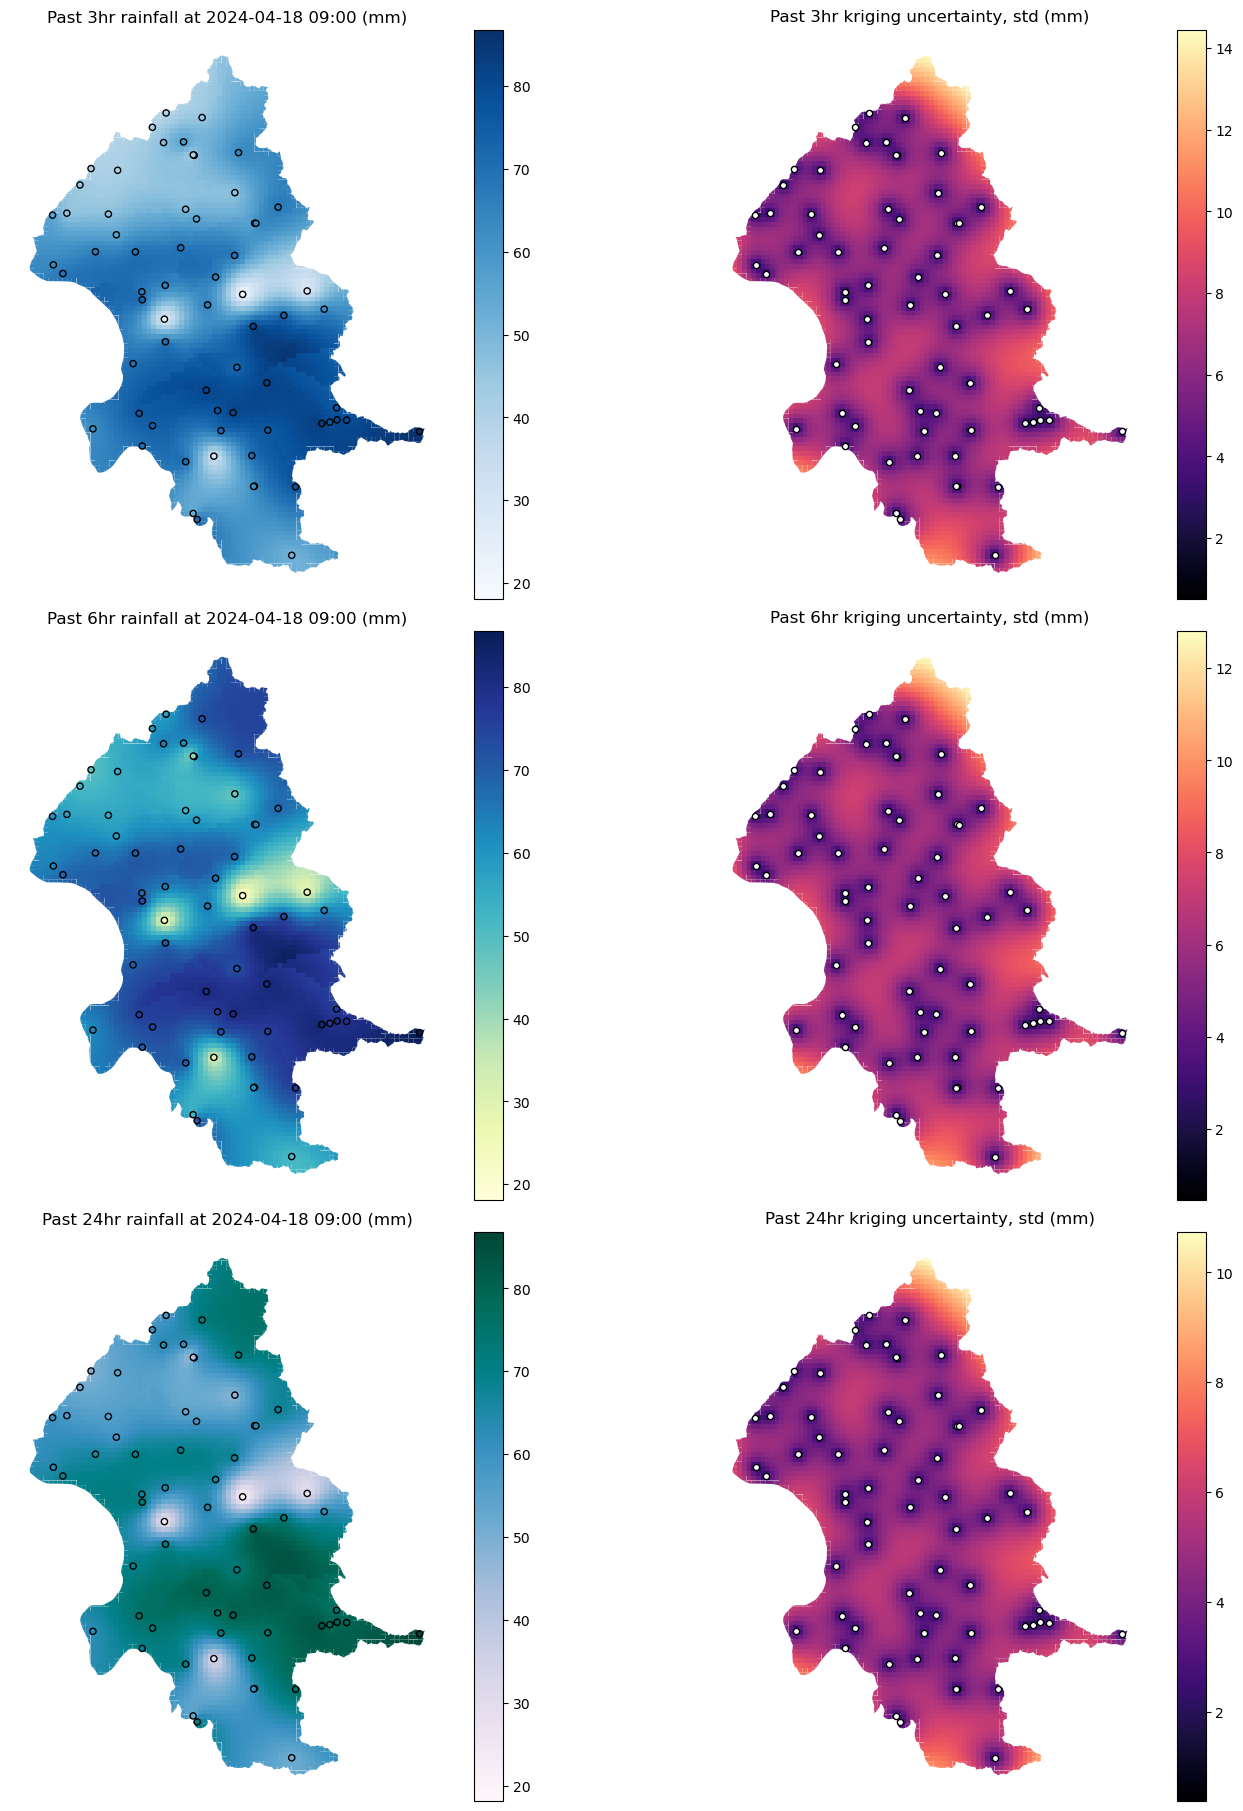

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 測站轉成 GDF，用來疊在圖上
rain_past3hr_gdf = gpd.GeoDataFrame(
    rain_past3hr_station,
    geometry=gpd.points_from_xy(
        rain_past3hr_station["StationLongitude"],
        rain_past3hr_station["StationLatitude"],
    ),
    crs="EPSG:4326",
).to_crs(TARGET_CRS)

rain_past6hr_gdf = gpd.GeoDataFrame(
    rain_past6hr_station,
    geometry=gpd.points_from_xy(
        rain_past6hr_station["StationLongitude"],
        rain_past6hr_station["StationLatitude"],
    ),
    crs="EPSG:4326",
).to_crs(TARGET_CRS)

rain_past24hr_gdf = gpd.GeoDataFrame(
    rain_past24hr_station,
    geometry=gpd.points_from_xy(
        rain_past24hr_station["StationLongitude"],
        rain_past24hr_station["StationLatitude"],
    ),
    crs="EPSG:4326",
).to_crs(TARGET_CRS)

fig, axes = plt.subplots(3, 2, figsize=(14, 18), constrained_layout=True)

rain_layers = [
    {
        "rain_col": "rain_past3hr_mm",
        "std_col": "rain_past3hr_std",
        "station_gdf": rain_past3hr_gdf,
        "title": f"Past 3hr rainfall at {target_time:%Y-%m-%d %H:%M} (mm)",
        "std_title": "Past 3hr kriging uncertainty, std (mm)",
        "cmap": "Blues",
    },
    {
        "rain_col": "rain_past6hr_mm",
        "std_col": "rain_past6hr_std",
        "station_gdf": rain_past6hr_gdf,
        "title": f"Past 6hr rainfall at {target_time:%Y-%m-%d %H:%M} (mm)",
        "std_title": "Past 6hr kriging uncertainty, std (mm)",
        "cmap": "YlGnBu",
    },
    {
        "rain_col": "rain_past24hr_mm",
        "std_col": "rain_past24hr_std",
        "station_gdf": rain_past24hr_gdf,
        "title": f"Past 24hr rainfall at {target_time:%Y-%m-%d %H:%M} (mm)",
        "std_title": "Past 24hr kriging uncertainty, std (mm)",
        "cmap": "PuBuGn",
    },
]

for row, layer in enumerate(rain_layers):
    # ===== 雨量分布 =====
    g_rain.plot(
        column=layer["rain_col"],
        ax=axes[row, 0],
        cmap=layer["cmap"],
        legend=True,
        linewidth=0,
    )

    layer["station_gdf"].plot(
        ax=axes[row, 0],
        column=layer["rain_col"],
        cmap=layer["cmap"],
        edgecolor="black",
        markersize=20,
    )

    axes[row, 0].set_title(layer["title"])
    axes[row, 0].set_axis_off()

    # ===== 不確定度分布 =====
    g_rain.plot(
        column=layer["std_col"],
        ax=axes[row, 1],
        cmap="magma",
        legend=True,
        linewidth=0,
    )

    layer["station_gdf"].plot(
        ax=axes[row, 1],
        color="white",
        edgecolor="black",
        markersize=20,
    )

    axes[row, 1].set_title(layer["std_title"])
    axes[row, 1].set_axis_off()

plt.show()

## 輸出含雨量資訊的 Grid 資料
---
此步驟將 Kriging 產生的三種雨量結果寫回臺北市 grid。每個 `grid_id` 只保留一筆資料，但同時包含 `Past3hr`、`Past6hr` 與 `Past24hr` 三種雨量資訊及其不確定度。

| 欄位 | 說明 |
|---|---|
| `rain_past3hr_mm` | 該網格的 Past 3-hour 雨量估計值 |
| `rain_past3hr_std` | Past 3-hour 雨量估計的不確定度 |
| `rain_past6hr_mm` | 該網格的 Past 6-hour 雨量估計值 |
| `rain_past6hr_std` | Past 6-hour 雨量估計的不確定度 |
| `rain_past24hr_mm` | 該網格的 Past 24-hour 雨量估計值 |
| `rain_past24hr_std` | Past 24-hour 雨量估計的不確定度 |
| `rain_target_time` | 本次分析使用的時間點 |

輸出檔案如下：

| 輸出檔案 | 說明 |
|---|---|
| `output/Taipei_grid_with_rain_post.geojson` | 含 geometry 的 grid 雨量空間資料 |
| `output/Taipei_grid_with_rain_post.csv` | 不含 geometry 的 grid 雨量屬性表 |

In [6]:
grid_rain = g.copy()

# ===== 同時保留三種雨量資訊 =====
grid_rain["rain_past3hr_mm"] = g_rain["rain_past3hr_mm"]
grid_rain["rain_past3hr_std"] = g_rain["rain_past3hr_std"]

grid_rain["rain_past6hr_mm"] = g_rain["rain_past6hr_mm"]
grid_rain["rain_past6hr_std"] = g_rain["rain_past6hr_std"]

grid_rain["rain_past24hr_mm"] = g_rain["rain_past24hr_mm"]
grid_rain["rain_past24hr_std"] = g_rain["rain_past24hr_std"]

# 紀錄分析時間
grid_rain["rain_target_time"] = target_time

# 確認一個 grid_id 只有一筆
print("grid 數量:", len(grid_rain))
print("不重複 grid_id 數量:", grid_rain["grid_id"].nunique())

display(
    grid_rain[
        [
            "grid_id",
            "rain_past3hr_mm",
            "rain_past3hr_std",
            "rain_past6hr_mm",
            "rain_past6hr_std",
            "rain_past24hr_mm",
            "rain_past24hr_std",
        ]
    ].head()
)

# ===== 輸出 =====
grid_rain.to_file(
    "output/Taipei_grid_with_rain_post.geojson",
    driver="GeoJSON",
    encoding="utf-8",
)

grid_rain.drop(columns="geometry").to_csv(
    "output/Taipei_grid_with_rain_post.csv",
    index=False,
    encoding="utf-8-sig",
)

grid 數量: 4585
不重複 grid_id 數量: 4585


,grid_id,rain_past3hr_mm,rain_past3hr_std,rain_past6hr_mm,rain_past6hr_std,rain_past24hr_mm,rain_past24hr_std
0,1,64.390278,8.722108,64.388619,7.731729,64.818393,6.285269
1,2,63.916884,8.807834,64.022080,7.807720,64.340301,6.352835
2,3,63.364097,8.686970,63.613413,7.700580,63.794735,6.270484
3,4,62.782877,8.457284,63.214579,7.496975,63.269051,6.107363
4,5,62.299169,8.279067,62.913721,7.338994,62.882083,5.979389


## `output/Taipei_post_map.html` visualize
---

In [7]:
import os
import folium
import geopandas as gpd
import pandas as pd
import branca.colormap as cm

os.makedirs("output", exist_ok=True)

# ===== 0) 選擇 Post Map 要顯示哪一種雨量 =====
# 可選："past3hr", "past6hr", "past24hr"
rain_mode = "past3hr"

RAIN_LAYER_CONFIG = {
    "past3hr": {
        "rain_source_col": "rain_past3hr_mm",
        "rain_std_col": "rain_past3hr_std",
        "rain_map_name": f"Past 3hr Rainfall at {target_time:%Y-%m-%d %H:%M}",
    },
    "past6hr": {
        "rain_source_col": "rain_past6hr_mm",
        "rain_std_col": "rain_past6hr_std",
        "rain_map_name": f"Past 6hr Rainfall at {target_time:%Y-%m-%d %H:%M}",
    },
    "past24hr": {
        "rain_source_col": "rain_past24hr_mm",
        "rain_std_col": "rain_past24hr_std",
        "rain_map_name": f"Past 24hr Rainfall at {target_time:%Y-%m-%d %H:%M}",
    },
}

if rain_mode not in RAIN_LAYER_CONFIG:
    raise ValueError("rain_mode 只能是 'past3hr', 'past6hr', 或 'past24hr'")

rain_source_col = RAIN_LAYER_CONFIG[rain_mode]["rain_source_col"]
rain_std_col = RAIN_LAYER_CONFIG[rain_mode]["rain_std_col"]
rain_map_name = RAIN_LAYER_CONFIG[rain_mode]["rain_map_name"]

# ===== 1) Prepare data =====
map_grid = g_rain.copy()
map_grid["rain_mm"] = map_grid[rain_source_col]
map_grid["rain_std"] = map_grid[rain_std_col]

# 數值四捨五入，讓 tooltip 較容易閱讀
map_grid["rain_mm"] = map_grid["rain_mm"].round(2)
map_grid["rain_std"] = map_grid["rain_std"].round(2)

grid_wgs84 = map_grid.to_crs(epsg=4326).copy()
edges_wgs84 = edges_gdf.to_crs(epsg=4326).copy()
shelters_wgs84 = shelters.to_crs(epsg=4326).copy()

# 臺北市行政邊界
town_path = "data/TOWN_MOI_1140318/TOWN_MOI_1140318.shp"
town_gdf = gpd.read_file(town_path)
town_gdf.columns = [str(c).strip().strip("'").strip('"') for c in town_gdf.columns]

if "COUNTYCODE" in town_gdf.columns:
    tp_town = town_gdf[
        town_gdf["COUNTYCODE"].astype(str).str.contains("63000", na=False)
    ].copy()
elif "COUNTYNAME" in town_gdf.columns:
    tp_town = town_gdf[
        town_gdf["COUNTYNAME"].astype(str).str.contains("臺北市|台北市", na=False, regex=True)
    ].copy()
else:
    tp_town = town_gdf.copy()

tp_town_wgs84 = tp_town.to_crs(epsg=4326)

# ===== 2) Base map =====
minx, miny, maxx, maxy = grid_wgs84.total_bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="cartodbpositron",
)

# 讓 tooltip grid 位於最上層
folium.map.CustomPane(
    "grid_tooltip_pane",
    z_index=900,
    pointer_events=True,
).add_to(m)

# ===== 3) Rainfall grid =====
rain_min = float(grid_wgs84["rain_mm"].min())
rain_max = float(grid_wgs84["rain_mm"].max())

rain_cmap = cm.LinearColormap(
    colors=["#f7fbff", "#c6dbef", "#6baed6", "#2171b5", "#08306b"],
    vmin=rain_min,
    vmax=rain_max,
    caption=f"{rain_map_name} (mm)",
)

rain_fg = folium.FeatureGroup(name=f"Rainfall Grid: {rain_map_name}", show=True)

folium.GeoJson(
    grid_wgs84[["grid_id", "rain_mm", "rain_std", "geometry"]].to_json(),
    style_function=lambda feature: {
        "fillColor": rain_cmap(feature["properties"]["rain_mm"]),
        "color": "#333333",
        "weight": 0.45,
        "fillOpacity": 0.70,
        "opacity": 0.65,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.5,
        "fillOpacity": 0.85,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["grid_id", "rain_mm", "rain_std"],
        aliases=["Grid ID", "Rainfall (mm)", "Rainfall uncertainty std (mm)"],
        localize=True,
        labels=True,
        sticky=False,
    ),
    popup=folium.GeoJsonPopup(
        fields=["grid_id", "rain_mm", "rain_std"],
        aliases=["Grid ID", "Rainfall (mm)", "Rainfall uncertainty std (mm)"],
        localize=True,
        labels=True,
        max_width=280,
    ),
).add_to(rain_fg)

rain_fg.add_to(m)
rain_cmap.add_to(m)

# ===== 4) Original flood risk grid =====
risk_cmap = cm.LinearColormap(
    colors=["#ffffcc", "#ffeda0", "#feb24c", "#f03b20", "#bd0026"],
    vmin=float(grid_wgs84["total_flood_risk"].min()),
    vmax=float(grid_wgs84["total_flood_risk"].max()),
    caption="Original Total Flood Risk",
)

risk_fg = folium.FeatureGroup(name="Original Total Flood Risk", show=False)

risk_fields = [
    "grid_id",
    "total_flood_risk",
    "terrain_flood_risk",
    "river_flood_risk",
    "slope_risk",
    "geometry",
]

folium.GeoJson(
    grid_wgs84[risk_fields].to_json(),
    style_function=lambda feature: {
        "fillColor": risk_cmap(feature["properties"]["total_flood_risk"]),
        "color": "#444444",
        "weight": 0.35,
        "fillOpacity": 0.62,
        "opacity": 0.55,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.4,
        "fillOpacity": 0.78,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "grid_id",
            "total_flood_risk",
            "terrain_flood_risk",
            "river_flood_risk",
            "slope_risk",
        ],
        aliases=[
            "Grid ID",
            "Total Flood Risk",
            "Terrain Risk",
            "River Risk",
            "Slope Risk",
        ],
        localize=True,
        labels=True,
        sticky=False,
    ),
).add_to(risk_fg)

risk_fg.add_to(m)
risk_cmap.add_to(m)

# ===== 4.5) Slope risk grid =====
slope_cmap = cm.LinearColormap(
    colors=["#f7fcf0", "#ccebc5", "#7bccc4", "#2b8cbe", "#084081"],
    vmin=float(grid_wgs84["slope_risk"].min()),
    vmax=float(grid_wgs84["slope_risk"].max()),
    caption="Slope Risk",
)

slope_fg = folium.FeatureGroup(name="Slope Risk", show=False)

folium.GeoJson(
    grid_wgs84[["grid_id", "slope_risk", "geometry"]].to_json(),
    style_function=lambda feature: {
        "fillColor": slope_cmap(feature["properties"]["slope_risk"]),
        "color": "#444444",
        "weight": 0.35,
        "fillOpacity": 0.62,
        "opacity": 0.55,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.4,
        "fillOpacity": 0.78,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["grid_id", "slope_risk"],
        aliases=["Grid ID", "Slope Risk"],
        localize=True,
        labels=True,
        sticky=False,
    ),
).add_to(slope_fg)

slope_fg.add_to(m)
slope_cmap.add_to(m)

# ===== 5) Road layers =====
color_map = {
    "expressway": "#e31a1c",
    "arterial": "#1f78b4",
    "bridge": "#ff7f00",
    "residential": "#33a02c",
    "underground": "#6a3d9a",
    "service": "#999999",
}

edges_plot = edges_wgs84.copy()

if "road_type" in edges_plot.columns:
    edges_plot["road_type_std"] = (
        edges_plot["road_type"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"underground_road": "underground"})
    )
else:
    edges_plot["road_type_std"] = "residential"

for rt, color in color_map.items():
    sub = edges_plot[edges_plot["road_type_std"] == rt].copy()
    if sub.empty:
        continue

    fg = folium.FeatureGroup(name=f"Road: {rt}", show=True)

    folium.GeoJson(
        sub[["geometry", "road_type_std"]].to_json(),
        style_function=lambda feature, c=color: {
            "color": c,
            "weight": 1.3,
            "opacity": 0.85,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["road_type_std"],
            aliases=["Road Type"],
            labels=True,
            sticky=False,
        ),
    ).add_to(fg)

    fg.add_to(m)

# ===== 6) Taipei boundary =====
folium.GeoJson(
    tp_town_wgs84[["COUNTYNAME", "TOWNNAME", "geometry"]].to_json(),
    name="Taipei District Boundary",
    style_function=lambda feature: {
        "color": "#111111",
        "weight": 1.8,
        "fillOpacity": 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["COUNTYNAME", "TOWNNAME"],
        aliases=["County/City", "District"],
        labels=True,
        sticky=False,
    ),
).add_to(m)

# ===== 7) Shelters =====
def safe_get(row, col, default="N/A"):
    if col in row.index and pd.notna(row[col]):
        return str(row[col])
    return default


shelter_fg = folium.FeatureGroup(name="Shelters", show=True)

for _, row in shelters_wgs84.iterrows():
    name = safe_get(row, "避難收容處所名稱")
    addr = safe_get(row, "避難收容處所地址")
    cap = safe_get(row, "預計收容人數")
    town = safe_get(row, "縣市及鄉鎮市區")
    sid = safe_get(row, "shelter_id")

    popup_html = f"""
    <b>避難收容處所名稱:</b> {name}<br>
    <b>Shelter ID:</b> {sid}<br>
    <b>行政區:</b> {town}<br>
    <b>地址:</b> {addr}<br>
    <b>預計收容人數:</b> {cap}
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color="#111111",
        weight=1,
        fill=True,
        fill_color="#ffdd00",
        fill_opacity=0.95,
        popup=folium.Popup(popup_html, max_width=360),
        tooltip=name,
    ).add_to(shelter_fg)

shelter_fg.add_to(m)

# ===== 8) Top grid tooltip layer: rain + risk together =====
tooltip_cols = [
    "grid_id",
    "rain_mm",
    "rain_std",
    "total_flood_risk",
    "terrain_flood_risk",
    "river_flood_risk",
    "slope_risk",
    "geometry",
]

folium.GeoJson(
    grid_wgs84[tooltip_cols].to_json(),
    name="Grid Tooltip: Rainfall + Risk",
    pane="grid_tooltip_pane",
    style_function=lambda feature: {
        "color": "#111111",
        "weight": 0.25,
        "opacity": 0.35,
        "fillColor": "#ffffff",
        "fillOpacity": 0.01,
    },
    highlight_function=lambda feature: {
        "color": "#000000",
        "weight": 1.5,
        "opacity": 1.0,
        "fillColor": "#ffffff",
        "fillOpacity": 0.08,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "grid_id",
            "rain_mm",
            "rain_std",
            "total_flood_risk",
            "terrain_flood_risk",
            "river_flood_risk",
            "slope_risk",
        ],
        aliases=[
            "Grid ID",
            "Rainfall (mm)",
            "Rainfall std (mm)",
            "Total Flood Risk",
            "Terrain Risk",
            "River Risk",
            "Slope Risk",
        ],
        localize=True,
        labels=True,
        sticky=False,
    ),
    show=True,
    control=True,
).add_to(m)

# ===== 9) Control & save =====
folium.LayerControl(collapsed=False).add_to(m)

map_path = "output/Taipei_post_map.html"
m.save(map_path)

print("Saved:", map_path)

Saved: output/Taipei_post_map.html


## 道路車速函式定義
---
本研究將道路災害情境下的通行能力拆成三個問題：

1. 現在雨勢是否會造成車速下降？
2. 近 6 小時累積雨量是否造成淹水影響？
3. 近 24 小時累積雨量是否造成坡地或土石流危害？

因此，道路災後速度定義為：

**post_speed_kph = normal_speed_kph × rainfall_speed_factor × flood_factor × landslide_factor**

若任一因子為 `0.00`，則該路段視為封閉或不建議通行。

---

### Normal speed for all types of roads

| road_type | normal_speed_kph | Description |
|---|---:|---|
| expressway | 90 | Expressways or high-capacity roads with faster through traffic |
| arterial | 60 | Major urban roads supporting cross-district movement |
| bridge | 60 | Bridge or viaduct segments with important network connectivity |
| underground | 50 | Underground roads, tunnels, or underpasses |
| residential | 50 | Local streets and residential roads |
| service | 30 | Service roads, access roads, or low-priority local connections |

---

### Rainfall influences on flooding (Past 6 hours)

Past 6-hour rainfall is used to represent short-term accumulated rainfall pressure related to urban flooding. Flooding impact is evaluated together with the static `total_flood_risk` score.

Based on validation results, `total_flood_risk >= 3` is treated as the warning threshold for flood-prone grids. The rainfall thresholds are aligned with the external flood validation scenarios: `78.8 mm`, `100 mm`, and `130 mm`.

The final flood impact factor is defined as:

**flooding_factor = flood_risk_rainfall_factor × road_type_flood_factor**

---

#### Flood risk level

| total_flood_risk | Flood susceptibility |
|---|---|
| 0 | safe |
| 1-2 | warn |
| 3-4 | slight danger |
| 5 | danger |
| 6 | extreme danger |

---

#### Flood risk rainfall factor

| Flood susceptibility | <= 78.8 mm | > 78.8 mm | > 100 mm | > 130 mm |
|---|---:|---:|---:|---:|
| safe | 1.00 | 1.00 | 1.00 | 1.00 |
| warn | 1.00 | 1.00 | 1.00 | 1.00 |
| slight danger | 1.00 | 0.85 | 0.75 | 0.65 |
| danger | 1.00 | 0.75 | 0.60 | 0.45 |
| extreme danger | 1.00 | 0.60 | 0.40 | 0.20 |

#### 計算 flooding_factor 時，safe 和 warn 可以一樣。報告解讀時，warn 仍然是「注意區」，不是完全安全。
---

#### Road type flood factor

| road_type | safe | warn | slight danger | danger | extreme danger |
|---|---:|---:|---:|---:|---:|
| expressway | 1.00 | 0.90 | 0.90 | 0.90 | 0.90 |
| arterial | 1.00 | 0.80 | 0.80 | 0.80 | 0.80 |
| bridge | 1.00 | 0.70 | 0.70 | 0.70 | 0.70 |
| underground | 1.00 | 0.50 | 0.00 | 0.00 | 0.00 |
| residential | 1.00 | 0.70 | 0.70 | 0.70 | 0.70 |
| service | 1.00 | 0.60 | 0.60 | 0.60 | 0.60 |

Underground roads are treated as closed once flooding impact is triggered because underpasses and tunnels are highly sensitive to accumulated rainfall and drainage failure.

The `road_type_flood_factor` is applied only when Past 6-hour rainfall exceeds `78.8 mm`. If Past 6-hour rainfall is less than or equal to `78.8 mm`, the flood impact factor remains `1.00`.

---

### Rainfall influences on flooding (Past 6 hours)

Past 6-hour rainfall is used to represent short-term accumulated rainfall pressure related to urban flooding. Flooding impact is evaluated together with the static `total_flood_risk` score.

The `total_flood_risk` score ranges from 0 to 7. A higher score indicates that flooding impact is triggered under a lower rainfall threshold.

| total_flood_risk | Flood susceptibility | Moderate Flood threshold | Severe Flood threshold |
|---|---|---:|---:|
| 0 | safe  | None | None |
| 1-2 | warm | > 80 mm | > 120 mm |
| 3-4 | slight danger | > 60 mm | > 100 mm |
| 5 | danger | > 40 mm | > 80 mm |
| 6 | extreme danger | > 30 mm | > 70 mm |

When Past 6-hour rainfall exceeds the threshold of a grid, roads located in that grid are treated as flood-affected. Flood-affected roads receive additional speed penalties according to road type.

| road_type | Moderate flood_factor | Severe flood_factor |
|---|--:|--:|
| expressway | 0.8 |0.6|
| arterial | 0.7 |0.5|
| bridge | 0.4 |0.3|
| underground | 0.00 |0.00|
| residential | 0.45 | 0.35 |
| service | 0.35 | 0.25 |

Underground roads are treated as closed once flooding impact is triggered because underpasses and tunnels are highly sensitive to accumulated rainfall and drainage failure.

---

### Rainfall influences on landsliding (Past 24 hours)

Past 24-hour rainfall is used to represent longer-term accumulated rainfall that may increase soil moisture and slope instability. Slope-related impact is evaluated together with the static `slope_risk` score.

The threshold does not indicate that slope failure will certainly occur. Instead, it represents the rainfall level at which slope-related road risk is considered significant enough to affect road accessibility. Higher `slope_risk` values require lower rainfall amounts to trigger road-speed penalties or possible avoidance.

| slope_risk | Meaning | Past 24-hour rainfall threshold for slope hazard |
|---:|---|---:|
| 0 | No debris-flow / slope hazard risk | No slope hazard assumed |
| 1 | Low slope hazard risk | > 200 mm |
| 2 | Medium slope hazard risk | > 140 mm |
| 3 | High slope hazard risk | > 80 mm |

When Past 24-hour rainfall exceeds the threshold of a grid, roads located in that grid are treated as slope-hazard affected.

| road_type | landslide_factor |
|---|---:|
| expressway | 0.80 |
| arterial | 0.65 |
| bridge | 0.60 |
| underground | 0.00 |
| residential | 0.50 |
| service | 0.40 |

Slope hazard does not automatically mean that every road is closed. Instead, it represents reduced accessibility due to higher slope-related uncertainty, possible debris, or road safety concerns.

In [ ]:
import numpy as np
import pandas as pd
import osmnx as ox

# ===== 1) Normal speed =====
ROAD_TYPE_NORMAL_SPEEDS = {
    "expressway": 90,
    "arterial": 60,
    "bridge": 60,
    "underground": 50,
    "residential": 50,
    "service": 30,
}

# ===== 2) Past 3hr rainfall speed factor =====
RAINFALL_SPEED_FACTOR_TABLE = {
    "expressway":  [1.00, 0.98, 0.95, 0.92, 0.88, 0.85, 0.80, 0.75, 0.70],
    "arterial":    [1.00, 0.97, 0.93, 0.88, 0.82, 0.78, 0.72, 0.65, 0.60],
    "bridge":      [1.00, 0.97, 0.92, 0.86, 0.80, 0.72, 0.65, 0.58, 0.50],
    "underground": [1.00, 0.95, 0.88, 0.78, 0.68, 0.58, 0.50, 0.42, 0.35],
    "residential": [1.00, 0.95, 0.90, 0.82, 0.75, 0.68, 0.60, 0.52, 0.45],
    "service":     [1.00, 0.93, 0.85, 0.75, 0.65, 0.55, 0.45, 0.35, 0.30],
}

# 對應欄位：
# <10, 10-20, 20-30, 30-40, 40-50, 50-60, 60-70, 70-80, >80
RAIN_BINS = [-np.inf, 10, 20, 30, 40, 50, 60, 70, 80, np.inf]


def clean_road_type(value):
    rt = str(value).strip().lower()

    if rt == "underground_road":
        rt = "underground"

    if rt in ROAD_TYPE_NORMAL_SPEEDS:
        return rt

    return "residential"


def get_rainfall_speed_factor(road_type, rain_past3hr_mm):
    road_type = clean_road_type(road_type)

    if pd.isna(rain_past3hr_mm):
        return 1.0

    bin_id = np.digitize([rain_past3hr_mm], RAIN_BINS, right=False)[0] - 1
    bin_id = int(np.clip(bin_id, 0, 8))

    return RAINFALL_SPEED_FACTOR_TABLE[road_type][bin_id]


# ===== 3) Flooding factor =====
# total_flood_risk:
# 0: safe
# 1-2: warn
# 3-4: slight danger
# 5: danger
# 6: extreme danger
#
# flooding_factor = flood_rainfall_factor * road_type_flood_factor
#
# 注意：
# - safe / warn 不做 flooding 額外折減
# - flooding factor 從 slight danger 開始啟動
# - Past 6hr rainfall thresholds 對齊 validation scenarios: 78.8 / 100 / 130

FLOOD_RISK_LEVELS = {
    0: "safe",
    1: "warn",
    2: "warn",
    3: "slight_danger",
    4: "slight_danger",
    5: "danger",
    6: "extreme_danger",
}

FLOOD_RAINFALL_FACTOR_TABLE = {
    "safe": [1.00, 1.00, 1.00, 1.00],
    "warn": [1.00, 1.00, 1.00, 1.00],
    "slight_danger": [1.00, 0.85, 0.75, 0.65],
    "danger": [1.00, 0.75, 0.60, 0.45],
    "extreme_danger": [1.00, 0.60, 0.40, 0.20],
}

ROAD_TYPE_FLOOD_FACTOR_TABLE = {
    "expressway": {
        "safe": 1.00,
        "warn": 1.00,
        "slight_danger": 0.90,
        "danger": 0.90,
        "extreme_danger": 0.90,
    },
    "arterial": {
        "safe": 1.00,
        "warn": 1.00,
        "slight_danger": 0.80,
        "danger": 0.80,
        "extreme_danger": 0.80,
    },
    "bridge": {
        "safe": 1.00,
        "warn": 1.00,
        "slight_danger": 0.70,
        "danger": 0.70,
        "extreme_danger": 0.70,
    },
    "underground": {
        "safe": 1.00,
        "warn": 1.00,
        "slight_danger": 0.00,
        "danger": 0.00,
        "extreme_danger": 0.00,
    },
    "residential": {
        "safe": 1.00,
        "warn": 1.00,
        "slight_danger": 0.70,
        "danger": 0.70,
        "extreme_danger": 0.70,
    },
    "service": {
        "safe": 1.00,
        "warn": 1.00,
        "slight_danger": 0.60,
        "danger": 0.60,
        "extreme_danger": 0.60,
    },
}


def get_flood_susceptibility(total_flood_risk):
    if pd.isna(total_flood_risk):
        return "safe"

    risk = int(total_flood_risk)
    risk = int(np.clip(risk, 0, 6))

    return FLOOD_RISK_LEVELS[risk]


def get_flood_rainfall_bin(rain_past6hr_mm):
    if pd.isna(rain_past6hr_mm):
        return 0

    if rain_past6hr_mm > 130:
        return 3
    if rain_past6hr_mm > 100:
        return 2
    if rain_past6hr_mm > 78.8:
        return 1

    return 0


def get_flood_level(total_flood_risk, rain_past6hr_mm):
    susceptibility = get_flood_susceptibility(total_flood_risk)
    rain_bin = get_flood_rainfall_bin(rain_past6hr_mm)

    # safe / warn 只作為觀察，不啟動 flooding impact
    if susceptibility in {"safe", "warn"}:
        return "none"

    if rain_bin == 3:
        return "extreme"
    if rain_bin == 2:
        return "danger"
    if rain_bin == 1:
        return "warning"

    return "none"


def get_flood_factor(road_type, total_flood_risk, rain_past6hr_mm):
    road_type = clean_road_type(road_type)

    susceptibility = get_flood_susceptibility(total_flood_risk)
    rain_bin = get_flood_rainfall_bin(rain_past6hr_mm)

    flood_rainfall_factor = FLOOD_RAINFALL_FACTOR_TABLE[susceptibility][rain_bin]
    road_type_flood_factor = ROAD_TYPE_FLOOD_FACTOR_TABLE[road_type][susceptibility]

    return flood_rainfall_factor * road_type_flood_factor


# ===== 4) Landslide thresholds and factors =====
# slope_risk:
# 0: none
# 1: >200
# 2: >140
# 3: >80
LANDSLIDE_FACTOR_TABLE = {
    "expressway": 0.80,
    "arterial": 0.65,
    "bridge": 0.60,
    "underground": 0.00,
    "residential": 0.50,
    "service": 0.40,
}


def get_landslide_triggered(slope_risk, rain_past24hr_mm):
    if pd.isna(slope_risk) or pd.isna(rain_past24hr_mm):
        return False

    risk = int(slope_risk)

    if risk <= 0:
        return False
    if risk == 1:
        return rain_past24hr_mm > 200
    if risk == 2:
        return rain_past24hr_mm > 140
    if risk >= 3:
        return rain_past24hr_mm > 80

    return False


def get_landslide_factor(road_type, slope_risk, rain_past24hr_mm):
    road_type = clean_road_type(road_type)

    if not get_landslide_triggered(slope_risk, rain_past24hr_mm):
        return 1.0

    return LANDSLIDE_FACTOR_TABLE[road_type]


def get_road_status(post_speed_kph, rainfall_factor, flood_factor, landslide_factor):
    if post_speed_kph <= 0 or min(rainfall_factor, flood_factor, landslide_factor) <= 0:
        return "closed"
    if post_speed_kph < 15:
        return "severe_slow"
    if post_speed_kph < 30:
        return "slow"
    return "normal"

### Road-Grid Disaster Travel Time Calculation
---
Deliver:
```
road_grid_traveling.csv
```
後續操作須配合`road_grid_traveling.csv`中的`road_grid_id`欄位去對齊`taipei_road_grid_segments.geojson`獲得geometry。

In [14]:
# ===== 5) Join road-grid segments with rainfall/risk grid =====
# grid_rain 需要已經有：
# rain_past3hr_mm, rain_past6hr_mm, rain_past24hr_mm,
# total_flood_risk, slope_risk

road_post = road_grid_segments.copy()

grid_cols = [
    "grid_id",
    "rain_past3hr_mm",
    "rain_past6hr_mm",
    "rain_past24hr_mm",
    "total_flood_risk",
    "slope_risk",
]

road_post = road_post.merge(
    grid_rain[grid_cols],
    on="grid_id",
    how="left",
)

road_post["road_type"] = road_post["road_type"].apply(clean_road_type)

road_post["normal_speed_kph"] = road_post["road_type"].map(ROAD_TYPE_NORMAL_SPEEDS)

road_post["rainfall_speed_factor"] = road_post.apply(
    lambda r: get_rainfall_speed_factor(
        r["road_type"],
        r["rain_past3hr_mm"],
    ),
    axis=1,
)

road_post["flood_level"] = road_post.apply(
    lambda r: get_flood_level(
        r["total_flood_risk"],
        r["rain_past6hr_mm"],
    ),
    axis=1,
)

road_post["flood_factor"] = road_post.apply(
    lambda r: get_flood_factor(
        r["road_type"],
        r["total_flood_risk"],
        r["rain_past6hr_mm"],
    ),
    axis=1,
)

road_post["landslide_triggered"] = road_post.apply(
    lambda r: get_landslide_triggered(
        r["slope_risk"],
        r["rain_past24hr_mm"],
    ),
    axis=1,
)

road_post["landslide_factor"] = road_post.apply(
    lambda r: get_landslide_factor(
        r["road_type"],
        r["slope_risk"],
        r["rain_past24hr_mm"],
    ),
    axis=1,
)

road_post["post_speed_kph"] = (
    road_post["normal_speed_kph"]
    * road_post["rainfall_speed_factor"]
    * road_post["flood_factor"]
    * road_post["landslide_factor"]
)

road_post["post_speed_kph"] = road_post["post_speed_kph"].round(2)

road_post["road_status"] = road_post.apply(
    lambda r: get_road_status(
        r["post_speed_kph"],
        r["rainfall_speed_factor"],
        r["flood_factor"],
        r["landslide_factor"],
    ),
    axis=1,
)

road_post["post_travel_time"] = np.where(
    road_post["post_speed_kph"] > 0,
    road_post["segment_length_m"] / (road_post["post_speed_kph"] * 1000 / 3600),
    np.inf,
)

display(
    road_post[
        [
            "road_grid_id",
            "grid_id",
            "road_type",
            "normal_speed_kph",
            "rain_past3hr_mm",
            "rain_past6hr_mm",
            "rain_past24hr_mm",
            "total_flood_risk",
            "slope_risk",
            "rainfall_speed_factor",
            "flood_level",
            "flood_factor",
            "landslide_triggered",
            "landslide_factor",
            "post_speed_kph",
            "road_status",
            "post_travel_time",
        ]
    ].head()
)

# ===== Save road-grid traveling result =====
road_grid_traveling_path = "output/road_grid_traveling.csv"

traveling_cols = [
    "road_grid_id",
    "road_base_id",
    "road_type",
    "road_no_in_type",
    "grid_id",
    "segment_length_m",
    "normal_speed_kph",
    "rain_past3hr_mm",
    "rain_past6hr_mm",
    "rain_past24hr_mm",
    "total_flood_risk",
    "slope_risk",
    "rainfall_speed_factor",
    "flood_level",
    "flood_factor",
    "landslide_triggered",
    "landslide_factor",
    "post_speed_kph",
    "road_status",
    "post_travel_time",
]

drop_cols = ["road_base_id", "road_type", "grid_id",  "road_no_in_type"]

road_post_export = road_post.drop(
    columns=[c for c in drop_cols if c in road_post.columns]
).copy()

traveling_cols_export = [
    c for c in traveling_cols
    if c in road_post_export.columns
]

road_post_export[traveling_cols_export].to_csv(
    road_grid_traveling_path,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", road_grid_traveling_path)
print("Rows:", len(road_post_export))

display(road_post_export[traveling_cols_export].head())

,road_grid_id,grid_id,road_type,normal_speed_kph,rain_past3hr_mm,rain_past6hr_mm,rain_past24hr_mm,total_flood_risk,slope_risk,rainfall_speed_factor,flood_level,flood_factor,landslide_triggered,landslide_factor,post_speed_kph,road_status,post_travel_time
0,arterial_01_g2025,2025,arterial,60,79.856422,79.856422,79.700498,3,0,0.65,warning,0.68,False,1.0,26.52,slow,18.574902
1,arterial_02_g2017,2017,arterial,60,63.043228,63.043228,63.452671,2,0,0.72,none,1.00,False,1.0,43.20,normal,2.752417
2,arterial_02_g2018,2018,arterial,60,67.123844,67.123844,67.206871,2,0,0.72,none,1.00,False,1.0,43.20,normal,2.049485
3,arterial_03_g1834,1834,arterial,60,79.248559,79.248559,79.462802,3,0,0.65,warning,0.68,False,1.0,26.52,slow,3.336738
4,arterial_04_g859,859,arterial,60,73.342514,73.342514,73.081162,3,0,0.65,none,0.80,False,1.0,31.20,normal,5.610303


Saved: output/road_grid_traveling.csv
Rows: 101018


,road_grid_id,segment_length_m,normal_speed_kph,rain_past3hr_mm,rain_past6hr_mm,rain_past24hr_mm,total_flood_risk,slope_risk,rainfall_speed_factor,flood_level,flood_factor,landslide_triggered,landslide_factor,post_speed_kph,road_status,post_travel_time
0,arterial_01_g2025,136.835109,60,79.856422,79.856422,79.700498,3,0,0.65,warning,0.68,False,1.0,26.52,slow,18.574902
1,arterial_02_g2017,33.029001,60,63.043228,63.043228,63.452671,2,0,0.72,none,1.00,False,1.0,43.20,normal,2.752417
2,arterial_02_g2018,24.593818,60,67.123844,67.123844,67.206871,2,0,0.72,none,1.00,False,1.0,43.20,normal,2.049485
3,arterial_03_g1834,24.580635,60,79.248559,79.248559,79.462802,3,0,0.65,warning,0.68,False,1.0,26.52,slow,3.336738
4,arterial_04_g859,48.622629,60,73.342514,73.342514,73.081162,3,0,0.65,none,0.80,False,1.0,31.20,normal,5.610303


In [ ]:
import folium
import geopandas as gpd
import pandas as pd
import numpy as np
import branca.colormap as cm

# ===== 1) 準備道路資料 =====
roads_map = road_post.copy()

if not isinstance(roads_map, gpd.GeoDataFrame):
    roads_map = road_grid_segments.merge(
        road_post,
        on="road_grid_id",
        how="left",
    )

roads_map = roads_map.to_crs(epsg=4326).copy()

roads_map["post_speed_kph_plot"] = (
    roads_map["post_speed_kph"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ===== 2) 準備 boundary =====
boundary_wgs84 = boundary.to_crs(epsg=4326)

# ===== 3) 準備 shelters =====
shelters_wgs84 = shelters.to_crs(epsg=4326).copy()

# ===== 4) Base map =====
minx, miny, maxx, maxy = boundary_wgs84.total_bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="cartodbpositron",
)

# ===== 5) 臺北市 boundary =====
folium.GeoJson(
    boundary_wgs84[["geometry"]].to_json(),
    name="Taipei Boundary",
    style_function=lambda feature: {
        "color": "#111111",
        "weight": 2,
        "fillOpacity": 0,
    },
).add_to(m)

# ===== 6) 道路速度 colormap =====
speed_min = 0
speed_max = float(roads_map["post_speed_kph_plot"].max())

speed_cmap = cm.LinearColormap(
    colors=["#111111", "#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"],
    vmin=speed_min,
    vmax=speed_max,
    caption="Post-disaster road speed (km/h)",
)

def road_style(feature):
    speed = feature["properties"].get("post_speed_kph_plot", 0)

    if speed <= 0:
        return {
            "color": "#111111",
            "weight": 2.2,
            "opacity": 0.95,
        }

    return {
        "color": speed_cmap(speed),
        "weight": 1.8,
        "opacity": 0.85,
    }

road_fields = [
    "road_grid_id",
    "normal_speed_kph",
    "post_speed_kph",
    "rain_past3hr_mm",
    "rain_past6hr_mm",
    "rain_past24hr_mm",
    "flood_level",
    "landslide_triggered",
    "post_travel_time",
    "post_speed_kph_plot",
    "geometry",
]
road_fields = [c for c in road_fields if c in roads_map.columns]

tooltip_pairs = [
    ("road_grid_id", "Road-grid ID"),
    ("normal_speed_kph", "Normal speed (km/h)"),
    ("post_speed_kph", "Post speed (km/h)"),
    ("rain_past3hr_mm", "Past 3hr rain (mm)"),
    ("rain_past6hr_mm", "Past 6hr rain (mm)"),
    ("rain_past24hr_mm", "Past 24hr rain (mm)"),
    ("flood_level", "Flood level"),
    ("landslide_triggered", "Landslide triggered"),
]
tooltip_pairs = [
    (field, alias)
    for field, alias in tooltip_pairs
    if field in roads_map.columns
]

tooltip_fields = [field for field, alias in tooltip_pairs]
tooltip_aliases = [alias for field, alias in tooltip_pairs]

road_fg = folium.FeatureGroup(name="Road Accessibility", show=True)

folium.GeoJson(
    roads_map[road_fields].to_json(),
    name="Road Accessibility",
    style_function=road_style,
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        labels=True,
        sticky=False,
    ),
).add_to(road_fg)

road_fg.add_to(m)
speed_cmap.add_to(m)

# ===== 7) 避難所圖層 =====
def safe_get(row, col, default="N/A"):
    if col in row.index and pd.notna(row[col]):
        return str(row[col])
    return default

shelter_fg = folium.FeatureGroup(name="Shelters", show=True)

for _, row in shelters_wgs84.iterrows():
    name = safe_get(row, "避難收容處所名稱")
    addr = safe_get(row, "避難收容處所地址")
    cap = safe_get(row, "預計收容人數")
    town = safe_get(row, "縣市及鄉鎮市區")
    sid = safe_get(row, "shelter_id")

    popup_html = f"""
    <b>避難收容處所名稱:</b> {name}<br>
    <b>Shelter ID:</b> {sid}<br>
    <b>行政區:</b> {town}<br>
    <b>地址:</b> {addr}<br>
    <b>預計收容人數:</b> {cap}
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color="#111111",
        weight=1,
        fill=True,
        fill_color="#ffdd00",
        fill_opacity=0.95,
        popup=folium.Popup(popup_html, max_width=360),
        tooltip=name,
    ).add_to(shelter_fg)

shelter_fg.add_to(m)

# ===== 8) Control & save =====
folium.LayerControl(collapsed=False).add_to(m)

map_path = "output/Taipei_road_accessibility_shelters_map.html"
m.save(map_path)

print("Saved:", map_path)

Saved: output/Taipei_road_accessibility_shelters_map.html
